# Architecture

## Tokenisation + Data Loading

In [1]:
import os

from socrates_ai.data_prep import TheFarmer
from socrates_ai.model_prep import Translator

farmer = TheFarmer()
tokeniser_path = os.path.join('..', 'data', 'tokenizer.json')

translator = Translator(cleaned_books_path = farmer.clean_dir)
oracle_tokens = translator.load_tokeniser(path=tokeniser_path)

In [2]:
import torch

from socrates_ai.helpers.training_helpers import load_book_paths, split_books_train_val

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

book_paths = load_book_paths(farmer.clean_dir)
print(f"{len(book_paths)} cleaned books found")

train_ids, val_ids = split_books_train_val(book_paths, oracle_tokens)
print(f"train tokens: {len(train_ids):,}")
print(f"val tokens:   {len(val_ids):,}")

Using device: cpu
634 cleaned books found
train tokens: 56,208,830
val tokens:   7,460,394


# Model

In [3]:
from socrates_ai.model_prep import MiniTransformer

model = MiniTransformer(
    vocab_size=oracle_tokens.get_vocab_size(),
    d_model=256,
    n_layers=4,
    n_heads=4,
    block_size=128,
    dropout=0.05,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")


Total parameters: 7,288,320


## Training

Three pieces: a helper to measure loss without training on it (`estimate_loss`), the actual training loop (`train_model`), and a plot of how loss moved over the run.

# Training Model Class

In [4]:
from socrates_ai.training import TrainingSocrates

In [ ]:
# reuses the `model` instantiated in the sanity-check cell above -- still
# untrained at this point unless you call load_checkpoint() below
trainer = TrainingSocrates(model, train_ids, val_ids, device=device, decay_target_steps=16000)


# to actually train (see the runtime note earlier in the notebook for how
# long this takes on this hardware):
# trainer.train(max_steps=5600, eval_interval=200, eval_iters=20)
# trainer.plot_training_curves()
# print(trainer.talk(oracle_tokens, "free will is", max_new_tokens=60, temperature=0.8))

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [10]:
trainer.train(max_steps=18000, eval_interval=200, eval_iters=40)

step   6001 | lr 2.20e-04 | train loss 4.4232 | val loss 4.4433
Saved checkpoint to ../data/checkpoints/step_6001.pt
step   6200 | lr 2.15e-04 | train loss 4.4013 | val loss 4.4243
Saved checkpoint to ../data/checkpoints/step_6200.pt
step   6400 | lr 2.10e-04 | train loss 4.3868 | val loss 4.3948
Saved checkpoint to ../data/checkpoints/step_6400.pt
step   6600 | lr 2.05e-04 | train loss 4.3840 | val loss 4.3971
Saved checkpoint to ../data/checkpoints/step_6600.pt
step   6800 | lr 2.00e-04 | train loss 4.3307 | val loss 4.3844
Saved checkpoint to ../data/checkpoints/step_6800.pt
step   7000 | lr 1.94e-04 | train loss 4.3285 | val loss 4.3414
Saved checkpoint to ../data/checkpoints/step_7000.pt
step   7200 | lr 1.89e-04 | train loss 4.2936 | val loss 4.3279
Saved checkpoint to ../data/checkpoints/step_7200.pt
step   7400 | lr 1.84e-04 | train loss 4.2779 | val loss 4.3183
Saved checkpoint to ../data/checkpoints/step_7400.pt
step   7600 | lr 1.78e-04 | train loss 4.2589 | val loss 4.3052


RuntimeError: [enforce fail at inline_container.cc:595] . unexpected pos 29973184 vs 29973076

In [11]:
# to resume a previous session instead of starting fresh, uncomment:
trainer.load_checkpoint()  # defaults to the most recent checkpoint

Loaded checkpoint from ../data/checkpoints/step_9000.pt (resuming from step 9000)


In [12]:
print(trainer.step)
trainer.decay_target_steps

9000


16000

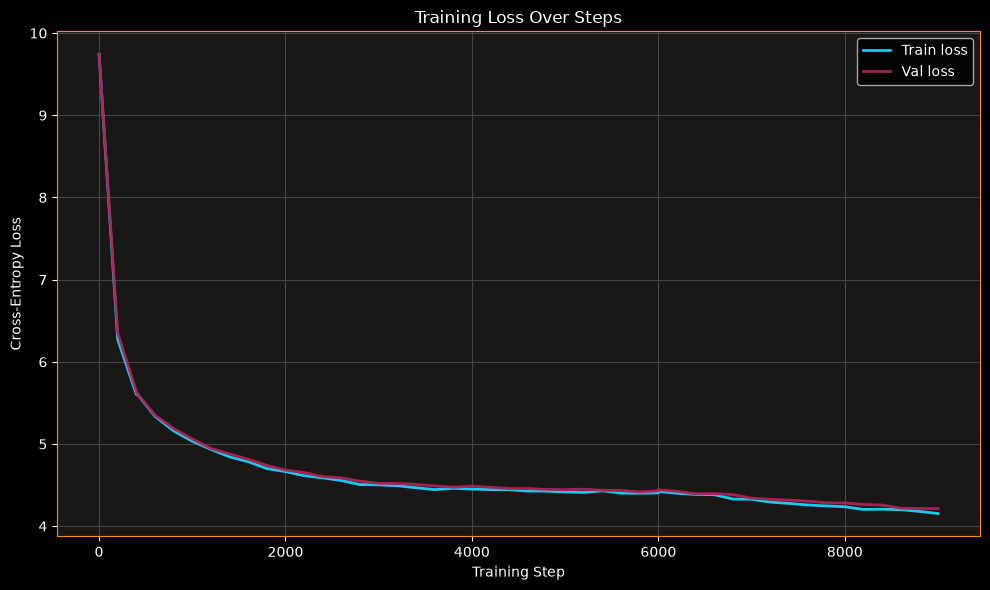

In [14]:
trainer.plot_training_curves()

In [18]:
myprompt = "Justice"
print(trainer.talk(tokeniser=oracle_tokens, prompt=myprompt, temperature=0.85))

 Justice, dehumility, seekfulness, propensity," and
illustrial improves, or, and can, in a state, mind, against
religious and materialistic merit, do not apply anything to the reasonable
subject, as to the necessary or supreme authority.

We know that what is negative is the essential imperative to our
recognition and to do something of our own. (The equality of
purpose is the determining for the recognition of the common wrong. The



# Benchmarks

Model trained on 50 books, 8000 token vocan size, outputs did not make sense, no real structure, some words were formed correctly

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
step     1 | train loss 8.7233 | val loss 8.7556
step    30 | train loss 6.9954 | val loss 7.1738
step    60 | train loss 6.5458 | val loss 6.8526
step    90 | train loss 6.3036 | val loss 6.6178
step   120 | train loss 6.0484 | val loss 6.3679
step   150 | train loss 5.8711 | val loss 6.1601
step   180 | train loss 5.7081 | val loss 6.0760
step   210 | train loss 5.6247 | val loss 5.9218
step   240 | train loss 5.5371 | val loss 5.8338
step   270 | train loss 5.4553 | val loss 5.7892
step   300 | train loss 5.4088 | val loss 5.7817

Training finished in 3693.6s